# 🔍 Exploratory Data Analysis

Quick EDA for a selected city and year from the **silver** layer.
Exports charts to `gold/notebook_exports/` for display in the Streamlit Insights page.

| Layer | What you get |
|-------|--------------|
| Silver | Cleaned, per-city/year CSVs — ideal for EDA |
| Gold   | Star-schema with dims joined — ideal for app/models |

In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")
from utils import (
    load, load_app_ready, describe, feature_matrix,
    plot_hourly, plot_monthly, plot_top_stations, plot_duration_dist, plot_city_comparison,
    export_df, export_figure,
    CITIES, CITY_DISPLAY_MAP,
)
print("Workspace utils loaded ✓")

2026-03-21 17:30:49.480 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-21 17:30:49.481 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-21 17:30:49.481 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-21 17:30:49.482 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-21 17:30:49.482 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-21 17:30:49.483 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Workspace utils loaded ✓


In [3]:
# ── Parameters — change these ─────────────────────────────────────────────────
CITY = "oslo"   # oslo | bergen | trondheim
YEAR = 2025     # int e.g. 2024, or None for all years

df = load(CITY, YEAR)
print(f"Loaded {len(df):,} trips for {CITY!r} ({YEAR or 'all years'})")
print(f"Columns: {list(df.columns)}")

Loaded 1,113,304 trips for 'oslo' (2025)
Columns: ['started_at', 'ended_at', 'duration_seconds', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'city_id', 'month', 'trip_id', 'start_station_id', 'end_station_id']


In [4]:
# Schema + null overview
describe(df)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,nulls,null_%,dtype
started_at,1113304,1062999,2025-08-26 07:01:30,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,object
ended_at,1113304,1064820,2025-07-10 13:31:01,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,object
duration_seconds,1113304.0,NaN,NaN,NaN,758.144837,832.775464,61.0,362.0,558.0,853.0,17888.0,0,0.0,int64
start_station_name,1113304,272,Alexander Kiellands Plass,13933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,object
start_station_latitude,1113304.0,NaN,NaN,NaN,59.921067,0.010621,59.898434,59.912711,59.91944,59.928067,59.953411,0,0.0,float64
start_station_longitude,1113304.0,NaN,NaN,NaN,10.747063,0.024227,10.651118,10.730589,10.750847,10.762213,10.814314,0,0.0,float64
end_station_name,1113304,272,Torggata,19077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,object
end_station_latitude,1113304.0,NaN,NaN,NaN,59.91868,0.009528,59.898434,59.911776,59.915983,59.924645,59.953411,0,0.0,float64
end_station_longitude,1113304.0,NaN,NaN,NaN,10.745577,0.02315,10.651118,10.731219,10.750462,10.760804,10.814314,0,0.0,float64
city_id,1113304.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0,0.0,int64


In [5]:
df.head(5)

,started_at,ended_at,duration_seconds,start_station_name,start_station_latitude,start_station_longitude,end_station_name,end_station_latitude,end_station_longitude,city_id,month,trip_id,start_station_id,end_station_id
0,2025-04-01 03:00:05,2025-04-01 03:11:29,683,Fredensborg,59.920995,10.750358,Fram-gården,59.915424,10.714577,1,april,oslo_2025_april_0,oslo:fredensborg,oslo:fram_garden
1,2025-04-01 03:00:22,2025-04-01 03:10:22,599,Sagene bussholdeplass,59.937743,10.751648,Volvat,59.933087,10.703968,1,april,oslo_2025_april_1,oslo:sagene_bussholdeplass,oslo:volvat
2,2025-04-01 03:16:44,2025-04-01 03:22:00,316,Elisenberg,59.919524,10.708840,Skøyen,59.922269,10.679580,1,april,oslo_2025_april_2,oslo:elisenberg,oslo:skyen
3,2025-04-01 03:19:07,2025-04-01 03:22:19,192,Enerhaugen,59.913202,10.767579,Vaterlandsparken,59.913516,10.757335,1,april,oslo_2025_april_3,oslo:enerhaugen,oslo:vaterlandsparken
4,2025-04-01 03:22:18,2025-04-01 03:36:28,850,Botanisk Hage vest,59.920128,10.768875,Økern Portal,59.930904,10.801940,1,april,oslo_2025_april_4,oslo:botanisk_hage_vest,oslo:kern_portal


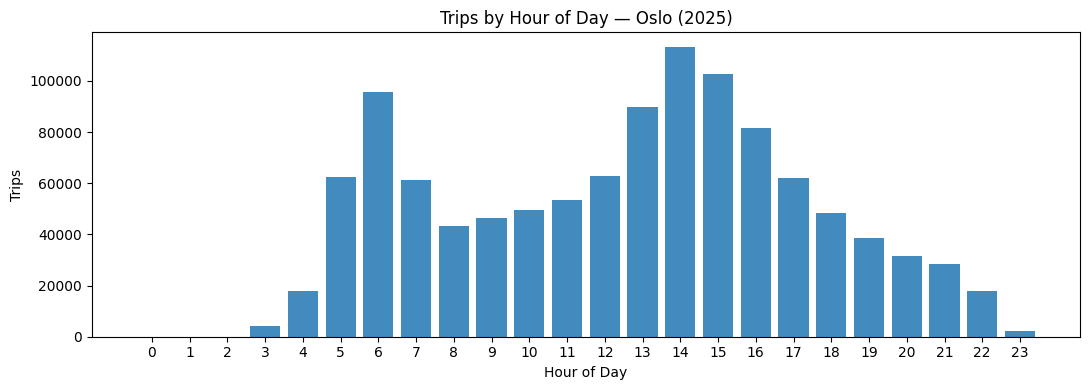

In [6]:
fig_hourly = plot_hourly(df, title=f"Trips by Hour of Day — {CITY.title()} ({YEAR or 'all years'})")

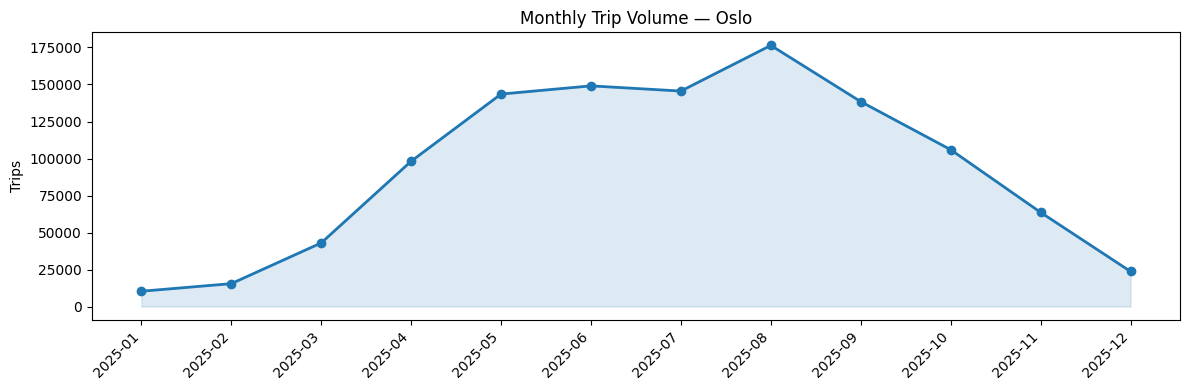

In [7]:
fig_monthly = plot_monthly(df, title=f"Monthly Trip Volume — {CITY.title()}")

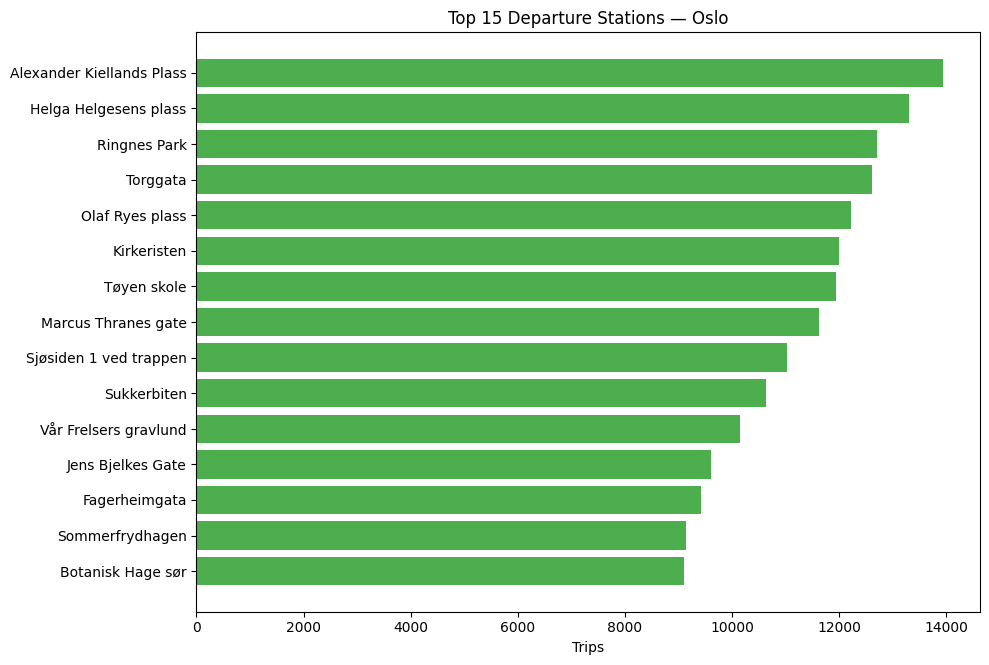

In [8]:
fig_stations = plot_top_stations(df, n=15, title=f"Top 15 Departure Stations — {CITY.title()}")

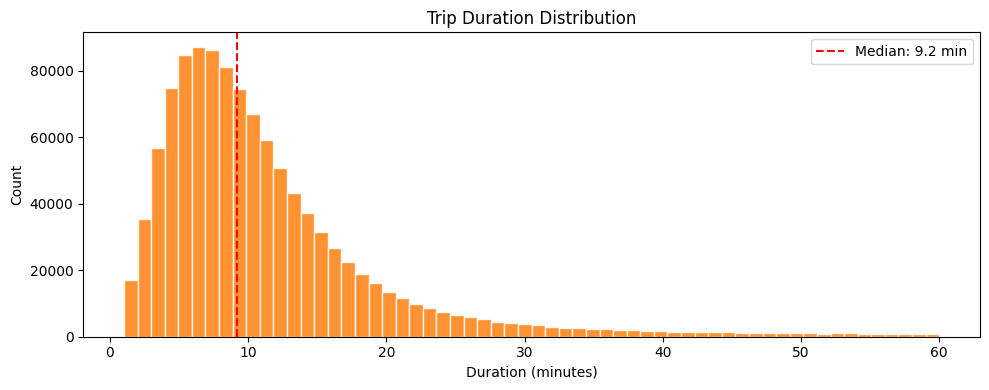

In [9]:
fig_duration = plot_duration_dist(df, max_minutes=60)

In [ ]:
# ── Export to Streamlit app ───────────────────────────────────────────────────
# These appear automatically in the Insights page after refreshing the app.
tag = f"{CITY}_{YEAR or 'all'}"
export_figure(f"eda_hourly_{tag}",   fig_hourly)
export_figure(f"eda_monthly_{tag}",  fig_monthly)
export_figure(f"eda_stations_{tag}", fig_stations)
export_figure(f"eda_duration_{tag}", fig_duration)
print("Exported to gold/notebook_exports/ ✓")
print("Refresh the Insights page in the Streamlit app to see them.")